In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report

In [28]:
data_path = Path('data/E_Commerce_Cleaned.csv')
df = pd.read_csv(data_path)

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 35 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   CustomerID                              5630 non-null   int64  
 1   Churn                                   5630 non-null   int64  
 2   Tenure                                  5630 non-null   float64
 3   CityTier                                5630 non-null   int64  
 4   WarehouseToHome                         5630 non-null   float64
 5   HourSpendOnApp                          5630 non-null   float64
 6   NumberOfDeviceRegistered                5630 non-null   int64  
 7   SatisfactionScore                       5630 non-null   int64  
 8   NumberOfAddress                         5630 non-null   int64  
 9   Complain                                5630 non-null   int64  
 10  OrderAmountHikeFromlastYear             5630 non-null   float64
 11  Co

In [30]:
df.sample(5)

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Tenure_is_missing,WarehouseToHome_is_missing,HourSpendOnApp_is_missing,OrderAmountHikeFromlastYear_is_missing,CouponUsed_is_missing,OrderCount_is_missing,DaySinceLastOrder_is_missing,PreferredLoginDevice_Phone,PreferredPaymentMode_COD,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile,PreferedOrderCat_Others,PreferedOrderCat_Phone,MaritalStatus_Married,MaritalStatus_Single
5118,55119,0,8.0,1,16.0,3.0,4,1,2,0,12.0,1.0,2.0,3.0,210.00,0,0,0,0,0,0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5556,55557,1,17.0,3,31.0,4.0,4,5,8,1,14.0,1.0,3.0,3.0,229.48,0,0,0,0,0,0,1,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5067,55068,0,18.0,3,12.0,3.0,4,4,9,0,15.0,2.0,4.0,11.0,307.13,0,0,0,1,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
704,50705,1,0.0,3,15.0,3.0,3,5,1,1,17.0,0.0,1.0,3.0,182.24,0,0,0,0,0,0,0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3470,53471,1,1.0,1,31.0,4.0,5,5,3,0,13.0,1.0,2.0,3.0,212.22,0,0,0,0,0,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Text(0.5, 1.0, 'Original Class Distribution')

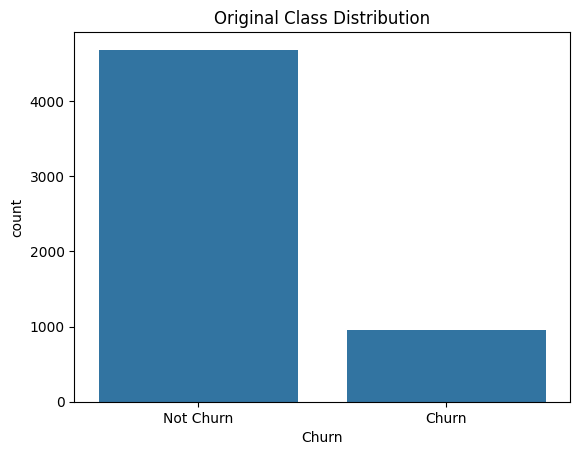

In [31]:
sns.countplot(data=df, x='Churn')
plt.xticks([0, 1], ['Not Churn', 'Churn'])
plt.title('Original Class Distribution')

In [32]:
X = df.drop(columns=['CustomerID','Churn'])  
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
smote=SMOTE(sampling_strategy='minority',random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

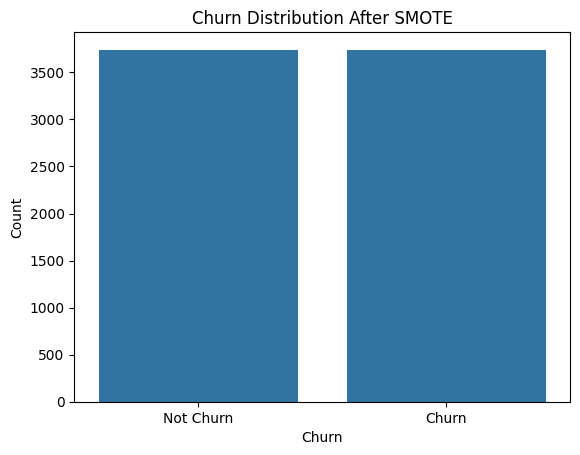

In [34]:
counts_sm = y_train_sm.value_counts()
sns.barplot(x=counts_sm.index, y=counts_sm.values)
plt.xticks([0,1],['Not Churn', 'Churn'])
plt.ylabel("Count")
plt.xlabel('Churn')
plt.title("Churn Distribution After SMOTE")
plt.show()

In [35]:
classifier=RandomForestClassifier(n_estimators=100,random_state=42)
classifier.fit(X_train_sm,y_train_sm)
y_pred=classifier.predict(X_test)

In [36]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 96.45%


In [37]:
conf_matrix = confusion_matrix(y_test, y_pred)

In [38]:
print(f'{classification_report(y_test,y_pred)}')

              precision    recall  f1-score   support

           0       0.96      0.99      0.98       941
           1       0.96      0.82      0.88       185

    accuracy                           0.96      1126
   macro avg       0.96      0.90      0.93      1126
weighted avg       0.96      0.96      0.96      1126



<Axes: >

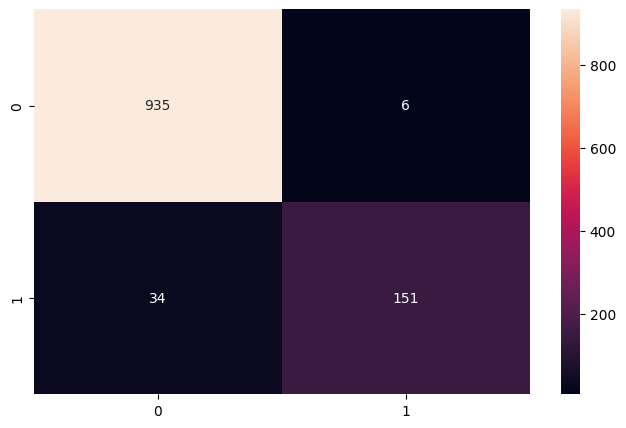

In [39]:
plt.figure(figsize=(8,5))
sns.heatmap(conf_matrix,annot=True,fmt='g',)

In [40]:
Path('../models').mkdir(exist_ok=True)

In [41]:
joblib.dump(classifier, '../models/classifier_model.pkl')

['../models/classifier_model.pkl']